In [ ]:
import sys
sys.path.append(r'../')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.d_CSL import *
from src.dataload import *
from src.dataPreProcessing import replace_nan

# if variables are changed on the fly 
from reloading import reloading
from tqdm.notebook import tqdm

No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


In [2]:
%reload_ext autoreload
%autoreload 2
from src.d_CSL import *

## Simulate data

An example ground truth connectivity matrix `A`

In [3]:
A = np.array([[0,1,0,0],
              [0,0,1,0],
              [0,0,0,0],
              [0,0,0,0]])
np.fill_diagonal(A, 1)

Text(0.5, 1.0, 'GT')

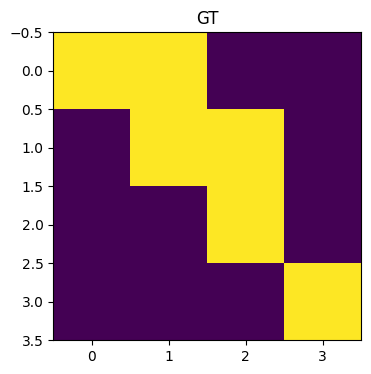

In [4]:
plt.figure(figsize=(4,4))
plt.imshow(A!=0)
plt.title('GT')

In [ ]:
df = pd.read_csv(r'./data/TCDF/demo_dataset.csv', header=0)
X_ = df.values
X = X_.T
print(X.shape)

(4, 4000)


## Analysis

In [6]:
N_PASTS, n_lags, n_perm = np.arange(2, 5, 1), 2, 1000
alpha, beta = 0.01, 0.001

In [7]:
infs_fgc = []
conf_mtx_fgc = []
shds_fgc = []
metrics_fgc = []
for i, n in enumerate(N_PASTS):
    print(f'{n} pasts')
    gcstar = GcStar(n_perm = 1000, 
                    n_pasts = n, 
                    n_lags = n_lags,
                    temporal = True,
                    method = 'fcgc')
    
    gcstar.fit(X, verbose = 0)
    inf = gcstar.get_connectivity_matrix(alpha=alpha, beta=beta, simulation=False)   # 
    infs_fgc.append(inf)
    conf_mtx_fgc.append(gcstar.compute_confusion_matrix(A))
    metrics_fgc.append(gcstar.all_metrics())
    shds_fgc.append(gcstar.compute_shd_sid(A, inf))
print('')
print('')

2 pasts


3 pasts
4 pasts




In [9]:
metrics_fgc

[array([1., 1., 1., 0., 1., 1.]),
 array([1., 1., 1., 0., 1., 1.]),
 array([1., 1., 1., 0., 1., 1.])]

In [10]:
infs_gc = []
conf_mtx_gc = []
shds_gc = []
metrics_gc = []
for i, n in enumerate(N_PASTS):
    print(f'{n} pasts')
    gcstar = GcStar(n_perm = 1000, 
                    n_pasts = n, 
                    n_lags = n_lags,
                    temporal = True,
                    method = 'cgc')
    
    gcstar.fit(X, verbose = 0)
    inf = gcstar.get_connectivity_matrix(alpha=alpha, beta=beta, simulation=False)   # 
    infs_gc.append(inf)
    conf_mtx_gc.append(gcstar.compute_confusion_matrix(A))
    metrics_gc.append(gcstar.all_metrics())
    shds_gc.append(gcstar.compute_shd_sid(A, inf))
print('')
print('')

2 pasts
3 pasts
4 pasts




In [11]:
metrics_gc

[array([1., 1., 1., 0., 1., 1.]),
 array([1., 1., 1., 0., 1., 1.]),
 array([1., 1., 1., 0., 1., 1.])]